<a href="https://colab.research.google.com/github/mperumal-usd/capstone_team_3/blob/main/notebooks/Added_to_final/COLAB_MERT_Finetune_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COLAB_MERT_Finetune_v5.ipynb

# MERT Fine-Tuning with LoRA: Composer Similarity (v5)

Fine-tunes `m-a-p/MERT-v1-95M` using LoRA adapters on all attention projections.
No projection head — the 768-dim L2-normalized MERT output is used directly with TripletMarginLoss.

## Sections
- **Section 0** — Setup (install deps, mount Drive, config)
- **Section 1** — Triplet CSV generation (always regenerated)
- **Section 2** — Train/val split (skips if Drive files exist)
- **Section 3** — LoRA training (intra-epoch checkpointing every N steps)
- **Section 4** — Evaluation

**Resume after disconnect:** Run all cells top-to-bottom. Each section checks Drive for its checkpoint and skips if already done. Training resumes from the last saved step.

In [9]:
# ── Section 0: Setup ──────────────────────────────────────────────────────────
!pip install -q transformers peft accelerate librosa numpy pandas scikit-learn tqdm

from google.colab import drive
drive.mount('/content/drive')

import os, json, random, re
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import librosa
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
DRIVE_BASE   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5"
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
MODEL_NAME       = "m-a-p/MERT-v1-95M"
MODEL_CACHE_DIR  = "/content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache"
SR           = 24000
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]
MARGIN       = 0.3
CNN_FILTERS  = 256           # filters per scale in CNN temporal encoder
CNN_KERNELS  = (3, 5, 7)     # multi-scale kernel sizes (frames)
EMBED_DIM    = 128           # final embedding dimension
BATCH_SIZE   = 8        # each triplet = 3 WAV forward passes through MERT
LR           = 5e-5
EPOCHS       = 10
SAVE_STEPS   = 1        # save full checkpoint to Drive after every optimizer step
GRAD_CLIP    = 1.0      # gradient clipping max norm (0 = disabled)
SEED         = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# Create Drive subdirectories
for sub in ["splits", "checkpoints/lora_best", "checkpoints/lora_last", "results", "model_cache"]:
    os.makedirs(os.path.join(DRIVE_BASE, sub), exist_ok=True)
print("Drive folders ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
Drive folders ready.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [6]:
CHUNK_PATH   = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/ChunkSamples"
TRIPLET_CSV = "/content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5/triplet_df.csv"

## Section 1 — Triplet CSV Generation
Regenerates (anchor, positive, negative) DataFrame from ChunkSamples and saves to Drive.
Always re-runs (~30 seconds). Anchor = first chunk of each song; positives = remaining chunks;
negative = chunks from a randomly chosen different composer.

In [ ]:
# ── Section 1: Triplet CSV ────────────────────────────────────────────────────
TRIPLET_CSV = os.path.join(DRIVE_BASE, "triplet_df.csv")

def numeric_sort(f):
    match = re.search(r'_chunk_(\d+)\.wav$', f)
    return int(match.group(1)) if match else -1

data = []
used_negatives = set()

for composer in os.listdir(CHUNK_PATH):
    composer_path = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(composer_path):
        continue
    for song in os.listdir(composer_path):
        song_path = os.path.join(composer_path, song)
        if not os.path.isdir(song_path):
            continue
        chunks = sorted(
            [f for f in os.listdir(song_path) if f.endswith(".wav")],
            key=numeric_sort
        )
        if len(chunks) < 2:
            continue
        anchor    = chunks[0]
        positives = chunks[1:]
        other_composers = [
            c for c in os.listdir(CHUNK_PATH)
            if c != composer and os.path.isdir(os.path.join(CHUNK_PATH, c))
        ]
        if not other_composers:
            continue
        chosen_composer      = random.choice(other_composers)
        chosen_composer_path = os.path.join(CHUNK_PATH, chosen_composer)
        negative_pool = []
        for other_song in sorted(os.listdir(chosen_composer_path)):
            other_song_path = os.path.join(chosen_composer_path, other_song)
            if not os.path.isdir(other_song_path):
                continue
            for f in sorted(os.listdir(other_song_path), key=numeric_sort):
                if f.endswith(".wav") and f not in used_negatives:
                    negative_pool.append(f)
        min_len = min(len(positives), len(negative_pool))
        for i in range(min_len):
            data.append({
                "anchor":   anchor,
                "positive": positives[i],
                "negative": negative_pool[i],
                "composer": composer,
                "song":     song,
            })
            used_negatives.add(negative_pool[i])

df = pd.DataFrame(data)
df.to_csv(TRIPLET_CSV, index=False)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

In [7]:
df = pd.read_csv(TRIPLET_CSV)
print(f"Triplet CSV saved → {TRIPLET_CSV}")
print(f"Total triplets: {len(df)}")
print(df.head())

Triplet CSV saved → /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5/triplet_df.csv
Total triplets: 23183
                 anchor              positive             negative composer  \
0  bach_847_chunk_1.wav  bach_847_chunk_2.wav  islamei_chunk_1.wav     bach   
1  bach_847_chunk_1.wav  bach_847_chunk_3.wav  islamei_chunk_2.wav     bach   
2  bach_847_chunk_1.wav  bach_847_chunk_4.wav  islamei_chunk_3.wav     bach   
3  bach_847_chunk_1.wav  bach_847_chunk_5.wav  islamei_chunk_4.wav     bach   
4  bach_847_chunk_1.wav  bach_847_chunk_6.wav  islamei_chunk_5.wav     bach   

       song  
0  bach_847  
1  bach_847  
2  bach_847  
3  bach_847  
4  bach_847  


## Section 2 — Train/Val Split
80/20 stratified split on composer. Skips if Drive files already exist.

In [8]:
# ── Section 2: Train/val split ────────────────────────────────────────────────
TRAIN_IDX_PATH = os.path.join(DRIVE_BASE, "splits", "train_idx.npy")
VAL_IDX_PATH   = os.path.join(DRIVE_BASE, "splits",   "val_idx.npy")

if os.path.exists(TRAIN_IDX_PATH) and os.path.exists(VAL_IDX_PATH):
    train_idx = np.load(TRAIN_IDX_PATH)
    val_idx   = np.load(VAL_IDX_PATH)
    print(f"Loaded split from Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")
else:
    all_idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        all_idx,
        test_size=0.2,
        random_state=SEED,
        stratify=df["composer"].values
    )
    np.save(TRAIN_IDX_PATH, train_idx)
    np.save(VAL_IDX_PATH,   val_idx)
    print(f"Split saved to Drive. Train: {len(train_idx)}  Val: {len(val_idx)}")

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
print(f"train_df: {len(train_df)} rows  val_df: {len(val_df)} rows")

Split saved to Drive. Train: 18546  Val: 4637
train_df: 18546 rows  val_df: 4637 rows


## Section 3 — LoRA Training

### Architecture
```
MERT-v1-95M
  + LoRA adapters on q_proj, k_proj, v_proj, o_proj (all transformer layers)
  → mean-pool last_hidden_state → 768-dim
  → L2-normalize → 768-dim unit-sphere embedding
Loss: TripletMarginLoss(margin=0.3)
```

### Resume behaviour
Training state is saved every `SAVE_STEPS` optimizer steps to Drive (`training_state.json`).
On resume, the LoRA adapter and optimizer are reloaded and the loop skips already-completed batches.

In [12]:
# ── Section 3A: Dataset + Model setup ────────────────────────────────────────

# Build filename → full path lookup
file_lookup = {}
for composer in os.listdir(CHUNK_PATH):
    cp = os.path.join(CHUNK_PATH, composer)
    if not os.path.isdir(cp):
        continue
    for song in os.listdir(cp):
        sp = os.path.join(cp, song)
        if not os.path.isdir(sp):
            continue
        for f in os.listdir(sp):
            if f.endswith(".wav"):
                file_lookup[f] = os.path.join(sp, f)
print(f"File lookup built: {len(file_lookup)} files")


class TripletWAVDataset(Dataset):
    """Loads WAV triplets on-the-fly from filenames."""
    def __init__(self, dataframe, file_lookup, processor, sr=24000):
        self.df          = dataframe.reset_index(drop=True)
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.df)

    def _load(self, fname):
        path  = self.file_lookup.get(fname)
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        # squeeze batch dim added by processor
        return {k: v.squeeze(0) for k, v in inputs.items()}

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return (
            self._load(row["anchor"]),
            self._load(row["positive"]),
            self._load(row["negative"]),
        )


def collate_triplets(batch):
    """Stack variable-length inputs by padding to the longest in the batch."""
    anchors, positives, negatives = zip(*batch)

    def stack(items):
        # items is a list of dicts; pad input_values to same length
        max_len = max(x["input_values"].shape[-1] for x in items)
        padded  = []
        for x in items:
            iv = x["input_values"]  # (seq_len,)
            pad_len = max_len - iv.shape[-1]
            padded.append(F.pad(iv, (0, pad_len)))
        return {"input_values": torch.stack(padded)}

    return stack(anchors), stack(positives), stack(negatives)


# ── Load processor + base model (Drive cache → HuggingFace fallback) ────────
if os.path.isdir(MODEL_CACHE_DIR) and os.listdir(MODEL_CACHE_DIR):
    print(f"Loading MERT from Drive cache: {MODEL_CACHE_DIR}")
    processor  = AutoProcessor.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
else:
    print("Drive cache not found. Downloading from HuggingFace...")
    processor  = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
    base_model = AutoModel.from_pretrained(MODEL_NAME, trust_remote_code=True)
    processor.save_pretrained(MODEL_CACHE_DIR)
    base_model.save_pretrained(MODEL_CACHE_DIR)
    print(f"Model cached to Drive: {MODEL_CACHE_DIR}")


# ── CNN Temporal Projection Head ────────────────────────────────────────────
import torch.nn as nn
class CNNProjectionHead(nn.Module):
    """
    Replaces mean-pooling with learned multi-scale temporal aggregation.

    Input : last_hidden_state  (batch, seq_len, 768)
    Output: L2-normalised embedding  (batch, EMBED_DIM)

    Three parallel Conv1d streams with different kernel sizes capture
    local (3-frame), mid (5-frame) and broader (7-frame) temporal patterns.
    Their global-average-pooled outputs are concatenated, then projected
    to EMBED_DIM via a two-layer MLP with LayerNorm + GELU.
    """
    def __init__(self, input_dim=768, num_filters=256,
                 kernel_sizes=(3, 5, 7), embed_dim=128, dropout=0.1):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(input_dim, num_filters, k, padding=k // 2),
                nn.BatchNorm1d(num_filters),
                nn.GELU(),
            )
            for k in kernel_sizes
        ])
        fused = num_filters * len(kernel_sizes)
        self.proj = nn.Sequential(
            nn.Linear(fused, fused // 2),
            nn.LayerNorm(fused // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fused // 2, embed_dim),
        )

    def forward(self, hidden_states: torch.Tensor) -> torch.Tensor:
        # hidden_states: (batch, seq_len, 768)
        x = hidden_states.transpose(1, 2)           # → (batch, 768, seq_len)
        pooled = [conv(x).mean(dim=2) for conv in self.convs]
        x = torch.cat(pooled, dim=1)                # (batch, num_filters * n_kernels)
        return F.normalize(self.proj(x), p=2, dim=1)  # (batch, embed_dim)


# Apply LoRA
lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGETS,
    lora_dropout=LORA_DROPOUT,
    bias="none",
)
model = get_peft_model(base_model, lora_config)
model.to(DEVICE)
model.print_trainable_parameters()

# Instantiate CNN projection head
cnn_head = CNNProjectionHead(
    input_dim    = 768,
    num_filters  = CNN_FILTERS,
    kernel_sizes = CNN_KERNELS,
    embed_dim    = EMBED_DIM,
    dropout      = 0.1,
).to(DEVICE)
cnn_params = sum(p.numel() for p in cnn_head.parameters())
print(f"CNN projection head: {cnn_params:,} params  (filters={CNN_FILTERS}, kernels={CNN_KERNELS}, embed={EMBED_DIM})")

# DataLoaders
train_dataset = TripletWAVDataset(train_df, file_lookup, processor, SR)
val_dataset   = TripletWAVDataset(val_df,   file_lookup, processor, SR)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_triplets, num_workers=2, pin_memory=True
)

criterion = torch.nn.TripletMarginLoss(margin=MARGIN, p=2)
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(cnn_head.parameters()), lr=LR
)
total_steps = EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)

print(f"Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")
print(f"Total training steps: {total_steps}")

# ── Mixed-precision (AMP) setup ──────────────────────────────────────────────
use_amp = DEVICE.type == "cuda"
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)
print(f"Mixed precision (AMP): {use_amp}")


File lookup built: 43663 files
Loading MERT from Drive cache: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/model_cache


The image processor of type `Wav2Vec2ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

trainable params: 442,368 || all params: 94,814,080 || trainable%: 0.4666
CNN projection head: 3,296,768 params  (filters=256, kernels=(3, 5, 7), embed=128)
Train batches: 2319  Val batches: 580
Total training steps: 23190
Mixed precision (AMP): True


In [13]:
# ── Section 3B: Training loop ─────────────────────────────────────────────────
LORA_BEST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_best")
LORA_LAST_DIR  = os.path.join(DRIVE_BASE, "checkpoints", "lora_last")
CNN_BEST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_best.pt")
CNN_LAST_PATH  = os.path.join(DRIVE_BASE, "checkpoints", "cnn_head_last.pt")
OPT_STATE_PATH = os.path.join(DRIVE_BASE, "checkpoints", "optimizer_state.pt")
TRAIN_STATE    = os.path.join(DRIVE_BASE, "checkpoints", "training_state.json")
LOG_PATH       = os.path.join(DRIVE_BASE, "training_log.csv")


def get_embedding(model, batch_inputs):
    """Forward through LoRA-MERT → CNN projection head → L2-normed EMBED_DIM embedding."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    return cnn_head(hidden)                 # (batch, EMBED_DIM) L2-normed


In [ ]:


# ── Resume ────────────────────────────────────────────────────────────────────
start_epoch   = 0
resume_step   = 0       # steps already completed inside start_epoch
global_step   = 0
best_val_loss = float("inf")
training_log  = []

if os.path.exists(TRAIN_STATE):
    with open(TRAIN_STATE) as f:
        state = json.load(f)
    start_epoch   = state["epoch"]
    resume_step   = state["step"]       # batches done in start_epoch
    global_step   = state["global_step"]
    best_val_loss = state["best_val_loss"]
    # Load a fresh base model so PeftModel.from_pretrained has no stale
    # peft_config attached — avoids the "Already found peft_config" warning
    # and guarantees the new optimizer points at the correct parameters.
    opt_ckpt = torch.load(OPT_STATE_PATH, map_location=DEVICE)
    fresh_base = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
    model = PeftModel.from_pretrained(fresh_base, LORA_LAST_DIR)
    model.to(DEVICE)
    if os.path.exists(CNN_LAST_PATH):
        cnn_head.load_state_dict(torch.load(CNN_LAST_PATH, map_location=DEVICE))
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(cnn_head.parameters()), lr=LR
    )
    optimizer.load_state_dict(opt_ckpt["optimizer"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    scheduler.load_state_dict(opt_ckpt["scheduler"])
    if "scaler" in opt_ckpt:
        scaler.load_state_dict(opt_ckpt["scaler"])
    print(f"Resumed: epoch={start_epoch} step={resume_step} global_step={global_step}")
else:
    print("No checkpoint found. Training from scratch.")

if os.path.exists(LOG_PATH):
    training_log = pd.read_csv(LOG_PATH).to_dict(orient="records")


def save_checkpoint(is_best=False, end_of_epoch=False):
    """Save LoRA adapter + optimizer/scheduler/scaler state to Drive.
    end_of_epoch=True advances epoch/step so resume skips no batches.
    """
    model.save_pretrained(LORA_LAST_DIR)
    torch.save(cnn_head.state_dict(), CNN_LAST_PATH)
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler":    scaler.state_dict(),
    }, OPT_STATE_PATH)
    with open(TRAIN_STATE, "w") as f:
        json.dump({
            "epoch":         epoch + 1 if end_of_epoch else epoch,
            "step":          0         if end_of_epoch else batch_idx + 1,
            "global_step":   global_step,
            "best_val_loss": best_val_loss,
        }, f)
    if is_best:
        model.save_pretrained(LORA_BEST_DIR)
        torch.save(cnn_head.state_dict(), CNN_BEST_PATH)


# ── Training ──────────────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    cnn_head.train()
    train_loss_total = 0.0
    train_batches    = 0

    for batch_idx, (a_in, p_in, n_in) in enumerate(
        tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [train]")
    ):
        # Skip already-completed batches on resume
        if epoch == start_epoch and batch_idx < resume_step:
            scheduler.step()
            global_step += 1
            continue

        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(model, a_in)
            p_emb = get_embedding(model, p_in)
            n_emb = get_embedding(model, n_in)
            loss  = criterion(a_emb, p_emb, n_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        if GRAD_CLIP > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                list(model.parameters()) + list(cnn_head.parameters()), GRAD_CLIP
            )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss_total += loss.item()
        train_batches    += 1
        global_step      += 1

        # Intra-epoch checkpoint
        if global_step % SAVE_STEPS == 0:
            save_checkpoint(is_best=False)

    avg_train_loss = train_loss_total / max(train_batches, 1)

    # ── Validation ────────────────────────────────────────────────────────────
    model.eval()
    cnn_head.eval()
    val_loss_total = 0.0
    val_pos_sim    = 0.0
    val_neg_sim    = 0.0

    with torch.no_grad():
        for a_in, p_in, n_in in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [val]"):
            with torch.cuda.amp.autocast(enabled=use_amp):
                a_emb = get_embedding(model, a_in)
                p_emb = get_embedding(model, p_in)
                n_emb = get_embedding(model, n_in)
                loss  = criterion(a_emb, p_emb, n_emb)
            val_loss_total += loss.item()
            val_pos_sim += F.cosine_similarity(a_emb, p_emb).mean().item()
            val_neg_sim += F.cosine_similarity(a_emb, n_emb).mean().item()

    avg_val_loss = val_loss_total / len(val_loader)
    avg_pos_sim  = val_pos_sim   / len(val_loader)
    avg_neg_sim  = val_neg_sim   / len(val_loader)

    # ── Log ───────────────────────────────────────────────────────────────────
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss

    row = {
        "epoch":       epoch + 1,
        "global_step": global_step,
        "train_loss":  round(avg_train_loss, 6),
        "val_loss":    round(avg_val_loss,   6),
        "val_pos_sim": round(avg_pos_sim,    4),
        "val_neg_sim": round(avg_neg_sim,    4),
        "val_gap":     round(avg_pos_sim - avg_neg_sim, 4),
        "lr":          optimizer.param_groups[0]["lr"],
        "best":        is_best,
    }
    training_log.append(row)
    pd.DataFrame(training_log).to_csv(LOG_PATH, index=False)

    # Save end-of-epoch checkpoint (and best if improved)
    save_checkpoint(is_best=is_best, end_of_epoch=True)
    resume_step = 0   # next epoch starts from batch 0

    print(
        f"Epoch {epoch+1:02d} | "
        f"train_loss={avg_train_loss:.4f} val_loss={avg_val_loss:.4f} "
        f"pos_sim={avg_pos_sim:.4f} neg_sim={avg_neg_sim:.4f} "
        f"gap={avg_pos_sim - avg_neg_sim:.4f}"
        + ("  ✓ best" if is_best else "")
    )

print(f"\nTraining complete. Best val_loss={best_val_loss:.4f}")
print(f"Best LoRA adapter → {LORA_BEST_DIR}")

No checkpoint found. Training from scratch.


Epoch 1/10 [train]:   0%|          | 0/2319 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_6588/1951960872.py:115: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Epoch 1/10 [val]: 100%|██████████| 580/580 [20:01<00:00,  2.07s/it]


Epoch 01 | train_loss=0.0993 val_loss=0.0950 pos_sim=0.5630 neg_sim=0.0784 gap=0.4846  ✓ best


Epoch 2/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.20it/s]


Epoch 02 | train_loss=0.0560 val_loss=0.0628 pos_sim=0.5149 neg_sim=-0.0997 gap=0.6145  ✓ best


...

Epoch 08 | train_loss=0.0125 val_loss=0.0404 pos_sim=0.5475 neg_sim=-0.0514 gap=0.5989


Epoch 9/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.21it/s]


Epoch 09 | train_loss=0.0110 val_loss=0.0302 pos_sim=0.5196 neg_sim=-0.1301 gap=0.6497  ✓ best


Epoch 10/10 [val]: 100%|██████████| 580/580 [00:38<00:00, 15.03it/s]

Epoch 10 | train_loss=0.0102 val_loss=0.0320 pos_sim=0.5208 neg_sim=-0.1277 gap=0.6486

Training complete. Best val_loss=0.0302
Best LoRA adapter → /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/checkpoints/lora_best


## Section 4 — Evaluation
Loads the best LoRA adapter and computes cosine similarity distributions on the val set.
Saves results and a 2-panel histogram to Drive.

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Best LoRA adapter loaded from /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5/checkpoints/lora_best
Best CNN head loaded  from /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5/checkpoints/cnn_head_best.pt


Evaluating:   0%|          | 0/580 [00:00<?, ?it/s]/tmp/ipykernel_5364/2500531831.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
Evaluating: 100%|██████████| 580/580 [38:48<00:00,  4.01s/it]


finetune_pos_mean  0.5196
finetune_neg_mean -0.1300
finetune_gap       0.6496
finetune_pos_std   0.2693
finetune_neg_std   0.2963


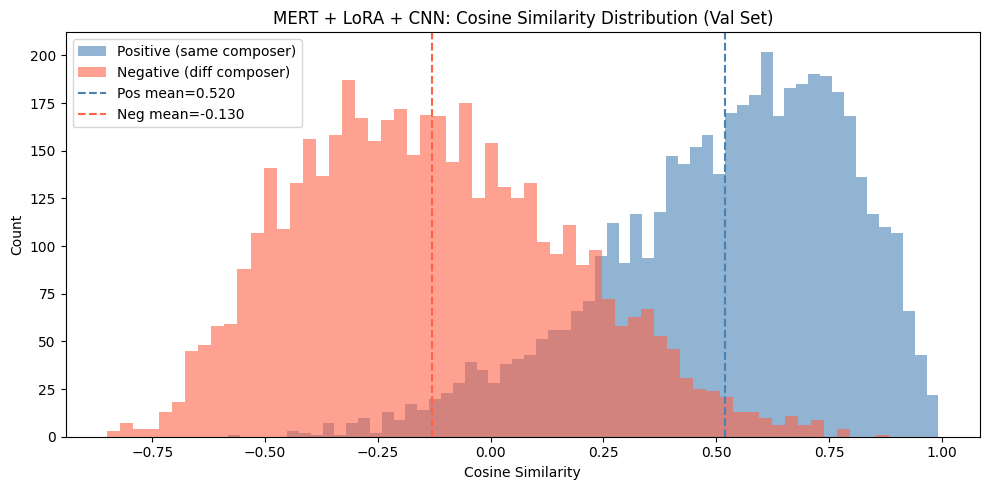

Plot saved → /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5/results/score_plot.png
Eval results saved → /content/drive/MyDrive/AAI-590 Capstone/AAI590_FinalProject/checkpoints5/results/eval_results.csv


In [14]:
# ── Section 4: Evaluation ─────────────────────────────────────────────────────
EVAL_CSV  = os.path.join(DRIVE_BASE, "results", "eval_results.csv")
PLOT_PATH = os.path.join(DRIVE_BASE, "results", "score_plot.png")

# Load best LoRA adapter + CNN projection head
eval_base  = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
eval_model = PeftModel.from_pretrained(eval_base, LORA_BEST_DIR)
eval_model.to(DEVICE)
eval_model.eval()
cnn_head.load_state_dict(torch.load(CNN_BEST_PATH, map_location=DEVICE))
cnn_head.eval()
print(f"Best LoRA adapter loaded from {LORA_BEST_DIR}")
print(f"Best CNN head loaded  from {CNN_BEST_PATH}")

# ── Compute fine-tuned cosine similarities on val set ─────────────────────────
ft_pos_sims, ft_neg_sims = [], []

with torch.no_grad():
    for a_in, p_in, n_in in tqdm(val_loader, desc="Evaluating"):
        with torch.cuda.amp.autocast(enabled=use_amp):
            a_emb = get_embedding(eval_model, a_in)
            p_emb = get_embedding(eval_model, p_in)
            n_emb = get_embedding(eval_model, n_in)
        ft_pos_sims.append(F.cosine_similarity(a_emb, p_emb).cpu().numpy())
        ft_neg_sims.append(F.cosine_similarity(a_emb, n_emb).cpu().numpy())

ft_pos_sim = np.concatenate(ft_pos_sims)
ft_neg_sim = np.concatenate(ft_neg_sims)

# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "finetune_pos_mean": round(float(ft_pos_sim.mean()), 4),
    "finetune_neg_mean": round(float(ft_neg_sim.mean()), 4),
    "finetune_gap":      round(float(ft_pos_sim.mean() - ft_neg_sim.mean()), 4),
    "finetune_pos_std":  round(float(ft_pos_sim.std()),  4),
    "finetune_neg_std":  round(float(ft_neg_sim.std()),  4),
}
results_df = pd.DataFrame([results])
results_df.to_csv(EVAL_CSV, index=False)
print(results_df.T.to_string(header=False))

# ── Distribution plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_pos_sim, bins=60, alpha=0.6, label="Positive (same composer)", color="steelblue")
ax.hist(ft_neg_sim, bins=60, alpha=0.6, label="Negative (diff composer)", color="tomato")
ax.axvline(ft_pos_sim.mean(), color="steelblue", linestyle="--", linewidth=1.5,
           label=f"Pos mean={ft_pos_sim.mean():.3f}")
ax.axvline(ft_neg_sim.mean(), color="tomato",    linestyle="--", linewidth=1.5,
           label=f"Neg mean={ft_neg_sim.mean():.3f}")
ax.set_title("MERT + LoRA + CNN: Cosine Similarity Distribution (Val Set)")
ax.set_xlabel("Cosine Similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_PATH, dpi=150)
plt.show()
print(f"Plot saved → {PLOT_PATH}")
print(f"Eval results saved → {EVAL_CSV}")

## Section 5 — Extract All Embeddings
Extracts embeddings for all chunks in the dataset using the best fine-tuned model and saves them to a DataFrame.

In [ ]:
# ── Section 5: Extract All Embeddings ─────────────────────────────────────────

all_files = list(file_lookup.keys())

class AllChunksDataset(Dataset):
    """Dataset for extracting embeddings from all chunks."""
    def __init__(self, file_list, file_lookup, processor, sr=24000):
        self.file_list   = file_list
        self.file_lookup = file_lookup
        self.processor   = processor
        self.sr          = sr

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        fname = self.file_list[idx]
        path  = self.file_lookup[fname]
        audio, _ = librosa.load(path, sr=self.sr)
        inputs   = self.processor(audio, sampling_rate=self.sr, return_tensors="pt")
        return fname, {k: v.squeeze(0) for k, v in inputs.items()}

def collate_all_chunks(batch):
    fnames, items = zip(*batch)
    max_len = max(x["input_values"].shape[-1] for x in items)
    padded  = []
    for x in items:
        iv = x["input_values"]
        pad_len = max_len - iv.shape[-1]
        padded.append(F.pad(iv, (0, pad_len)))
    return fnames, {"input_values": torch.stack(padded)}

all_dataset = AllChunksDataset(all_files, file_lookup, processor, SR)
all_loader  = DataLoader(
    all_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

results_data = []
eval_model.eval()
cnn_head.eval()

with torch.no_grad():
    for fnames, batch_inputs in tqdm(all_loader, desc="Extracting all embeddings"):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_embedding(eval_model, batch_inputs)
        embs_np = embs.cpu().numpy()

        for fname, emb in zip(fnames, embs_np):
            chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
            chunk_num = int(chunk_match.group(1)) if chunk_match else -1
            results_data.append({
                "filename": fname,
                "chunk": chunk_num,
                "embeddings": emb
            })

all_embeddings_df = pd.DataFrame(results_data)

# Save to pickle to preserve numpy arrays naturally
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
all_embeddings_df.to_pickle(EMBEDDINGS_PATH)

print(f"\nSaved {len(all_embeddings_df)} embeddings to {EMBEDDINGS_PATH}")
display(all_embeddings_df.head())

Extracting all embeddings: 100%|██████████| 5458/5458 [35:09<00:00,  2.59it/s]



Saved 43663 embeddings to /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/all_embeddings.pkl


,filename,chunk,embeddings
0,bach_847_chunk_1.wav,1,"[0.05016434, 0.069372244, -0.009370848, 0.0846..."
1,bach_847_chunk_2.wav,2,"[0.049578503, 0.091372475, 0.0034356404, 0.139..."
2,bach_847_chunk_3.wav,3,"[0.06047059, 0.08120336, 0.0074810754, 0.16503..."
3,bach_847_chunk_4.wav,4,"[0.06594905, 0.08882934, 0.0069581256, 0.17710..."
4,bach_847_chunk_5.wav,5,"[0.05413191, 0.11070533, 0.018642722, 0.173556..."


## Section 6 — FAISS Indexing and Evaluation
Builds a FAISS index from 80% of the chunk embeddings and queries the remaining 20% to measure **Recall@K** at the song level (i.e., whether a chunk from the same song appears in the top-K retrieved chunks).

In [ ]:
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 104.1 MB/s eta 0:00:00


In [ ]:
import faiss
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the 128-dim embeddings extracted in Section 5
EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "all_embeddings.pkl")
print(f"Loading embeddings from: {EMBEDDINGS_PATH}")
df_emb = pd.read_pickle(EMBEDDINGS_PATH)

# 2. Split 80% Index (Database) / 20% Validation (Queries)
train_df, val_df = train_test_split(df_emb, test_size=0.2, random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Total chunks: {len(df_emb)}")
print(f"Database (Index) size: {len(train_df)}")
print(f"Validation (Query) size: {len(val_df)}")

# 3. Build FAISS Index
# Our embeddings from the CNN head are 128-dim and L2-normalized.
d = EMBED_DIM
index = faiss.IndexFlatL2(d)

# Convert arrays to float32 contiguous arrays for FAISS
train_embs = np.vstack(train_df['embeddings'].values).astype('float32')
val_embs = np.vstack(val_df['embeddings'].values).astype('float32')

index.add(train_embs)
print(f"\nFAISS index built. Total vectors indexed: {index.ntotal}")

Loading embeddings from: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/all_embeddings.pkl
Total chunks: 43663
Database (Index) size: 34930
Validation (Query) size: 8733

FAISS index built. Total vectors indexed: 34930


In [ ]:
# 4. Calculate Recall@K
print("\n--- Calculating Recall@K on Validation Set ---")
max_k = 10
D_val, I_val = index.search(val_embs, max_k)

recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_filename = val_df.iloc[i]['filename']
    # Extract song name by stripping the chunk suffix (e.g. 'bach_847_chunk_1.wav' -> 'bach_847')
    query_song = query_filename.rsplit('_chunk_', 1)[0]

    # Get the filenames of the top K results
    match_filenames = train_df.iloc[I_val[i]]['filename'].values
    match_songs = [f.rsplit('_chunk_', 1)[0] for f in match_filenames]

    for k in recall_at_k.keys():
        # A match is successful if the SAME song is found in the top K
        if query_song in match_songs[:k]:
            recall_at_k[k] += 1

# 5. Display Results
results_data = []
for k, count in recall_at_k.items():
    recall = count / len(val_df)
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

recall_df = pd.DataFrame(results_data)
display(recall_df)


--- Calculating Recall@K on Validation Set ---
Recall@01: 0.6363
Recall@03: 0.7363
Recall@05: 0.7791
Recall@10: 0.8333


,K,Recall
0,1,0.636322
1,3,0.736288
2,5,0.779114
3,10,0.833276


/tmp/ipykernel_6588/718218038.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')


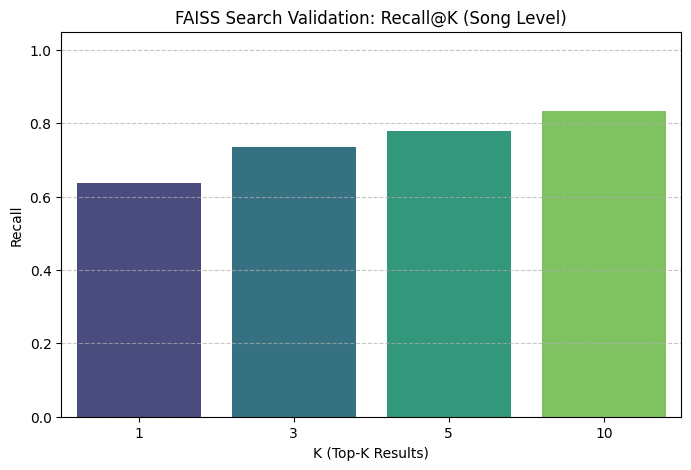

In [ ]:
# 6. Plot the Recall@K results
plt.figure(figsize=(8, 5))
sns.barplot(x='K', y='Recall', data=recall_df, palette='viridis')

plt.title('FAISS Search Validation: Recall@K (Song Level)')
plt.xlabel('K (Top-K Results)')
plt.ylabel('Recall')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Section 7 — Baseline Model Comparison
Extracts embeddings using the pre-trained base MERT model (mean-pooling over the last hidden state) for the exact same index and query sets to compare Recall@K against the fine-tuned model.

In [ ]:
# 1. Load the Base Model
print("Loading base MERT model for comparison...")
base_model = AutoModel.from_pretrained(MODEL_CACHE_DIR, trust_remote_code=True)
base_model.to(DEVICE)
base_model.eval()

def get_baseline_embedding(model, batch_inputs):
    """Standard mean-pooling over the last hidden state for the base model."""
    inputs = {k: v.to(DEVICE) for k, v in batch_inputs.items()}
    outputs = model(**inputs)
    hidden = outputs.last_hidden_state      # (batch, seq_len, 768)
    mean_pooled = hidden.mean(dim=1)        # (batch, 768)
    return F.normalize(mean_pooled, p=2, dim=1)

# 2. Create DataLoaders for the exact same split
train_files = train_df['filename'].tolist()
val_files = val_df['filename'].tolist()

base_train_dataset = AllChunksDataset(train_files, file_lookup, processor, SR)
base_val_dataset   = AllChunksDataset(val_files, file_lookup, processor, SR)

base_train_loader = DataLoader(
    base_train_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)
base_val_loader = DataLoader(
    base_val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
)

Loading base MERT model for comparison...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

In [ ]:
# 3. Extract Baseline Embeddings
base_train_embs_list = []
base_val_embs_list = []

print("Extracting baseline database (index) embeddings...")
with torch.no_grad():
    for fnames, batch_inputs in tqdm(base_train_loader):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_baseline_embedding(base_model, batch_inputs)
        base_train_embs_list.append(embs.cpu().numpy())

print("\nExtracting baseline validation (query) embeddings...")
with torch.no_grad():
    for fnames, batch_inputs in tqdm(base_val_loader):
        with torch.amp.autocast('cuda', enabled=use_amp):
            embs = get_baseline_embedding(base_model, batch_inputs)
        base_val_embs_list.append(embs.cpu().numpy())

base_train_embs = np.vstack(base_train_embs_list).astype('float32')
base_val_embs = np.vstack(base_val_embs_list).astype('float32')

Extracting baseline database (index) embeddings...


100%|██████████| 4367/4367 [01:15<00:00, 58.16it/s]



Extracting baseline validation (query) embeddings...


100%|██████████| 1092/1092 [00:19<00:00, 56.57it/s]


In [ ]:
# 4. Build Baseline FAISS Index & Calculate Recall@K
d_base = 768  # Base MERT hidden size
index_base = faiss.IndexFlatL2(d_base)
index_base.add(base_train_embs)
print(f"\nBaseline FAISS index built. Total vectors: {index_base.ntotal}")

print("\n--- Calculating Baseline Recall@K ---")
D_base_val, I_base_val = index_base.search(base_val_embs, max_k)

base_recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}

for i in range(len(val_df)):
    query_song = val_df.iloc[i]['filename'].rsplit('_chunk_', 1)[0]

    match_filenames = train_df.iloc[I_base_val[i]]['filename'].values
    match_songs = [f.rsplit('_chunk_', 1)[0] for f in match_filenames]

    for k in base_recall_at_k.keys():
        if query_song in match_songs[:k]:
            base_recall_at_k[k] += 1

base_results_data = []
for k, count in base_recall_at_k.items():
    recall = count / len(val_df)
    base_results_data.append({"K": k, "Recall": recall})
    print(f"Baseline Recall@{k:02d}: {recall:.4f}")

base_recall_df = pd.DataFrame(base_results_data)


Baseline FAISS index built. Total vectors: 34930

--- Calculating Baseline Recall@K ---
Baseline Recall@01: 0.4545
Baseline Recall@03: 0.5557
Baseline Recall@05: 0.6069
Baseline Recall@10: 0.6785


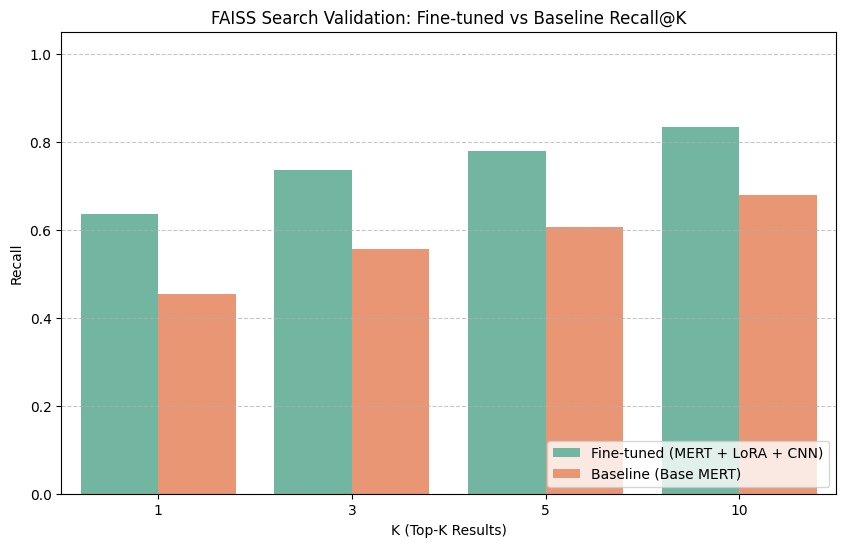

In [ ]:
# 5. Plot Comparison
recall_df['Model'] = 'Fine-tuned (MERT + LoRA + CNN)'
base_recall_df['Model'] = 'Baseline (Base MERT)'

combined_recall_df = pd.concat([recall_df, base_recall_df], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='K', y='Recall', hue='Model', data=combined_recall_df, palette='Set2')

plt.title('FAISS Search Validation: Fine-tuned vs Baseline Recall@K')
plt.xlabel('K (Top-K Results)')
plt.ylabel('Recall')
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()

In [ ]:
# 6. Save Comparison Results to CSV
COMPARISON_CSV = os.path.join(DRIVE_BASE, "results", "recall_comparison.csv")
combined_recall_df.to_csv(COMPARISON_CSV, index=False)
print(f"Comparison results saved to: {COMPARISON_CSV}")
display(combined_recall_df)

Comparison results saved to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/recall_comparison.csv


,K,Recall,Model
0,1,0.636322,Fine-tuned (MERT + LoRA + CNN)
1,3,0.736288,Fine-tuned (MERT + LoRA + CNN)
2,5,0.779114,Fine-tuned (MERT + LoRA + CNN)
3,10,0.833276,Fine-tuned (MERT + LoRA + CNN)
4,1,0.454483,Baseline (Base MERT)
5,3,0.555708,Baseline (Base MERT)
6,5,0.606893,Baseline (Base MERT)
7,10,0.678461,Baseline (Base MERT)


## Section 8 — Extract Embeddings for Testing Chunks
Extracts 128-dim embeddings for the testing chunks using the fine-tuned model (MERT + LoRA + CNN Head) and saves them to a DataFrame.

In [ ]:
# 1. Setup Test Directory and File Lookup
TEST_CHUNK_DIR = "/content/drive/MyDrive/AAI-590 Capstone/capstone_team_3/MidiDatasets/TestingSamples/TestChunks"

test_file_lookup = {}
if os.path.exists(TEST_CHUNK_DIR):
    for root, dirs, files in os.walk(TEST_CHUNK_DIR):
        for f in files:
            if f.endswith(".wav"):
                test_file_lookup[f] = os.path.join(root, f)
else:
    print(f"Directory not found: {TEST_CHUNK_DIR}")

test_files = list(test_file_lookup.keys())
print(f"Found {len(test_files)} test chunks.")

if len(test_files) > 0:
    # 2. Create Dataset and DataLoader
    test_dataset = AllChunksDataset(test_files, test_file_lookup, processor, SR)
    test_loader  = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        collate_fn=collate_all_chunks, num_workers=2, pin_memory=True
    )

    test_results_data = []
    eval_model.eval()
    cnn_head.eval()

    # 3. Extract Embeddings
    with torch.no_grad():
        for fnames, batch_inputs in tqdm(test_loader, desc="Extracting test embeddings"):
            with torch.amp.autocast('cuda', enabled=use_amp):
                embs = get_embedding(eval_model, batch_inputs)
            embs_np = embs.cpu().numpy()

            for fname, emb in zip(fnames, embs_np):
                chunk_match = re.search(r'_chunk_(\d+)\.wav$', fname)
                chunk_num = int(chunk_match.group(1)) if chunk_match else -1
                test_results_data.append({
                    "filename": fname,
                    "chunk": chunk_num,
                    "embeddings": emb
                })

    test_embeddings_df = pd.DataFrame(test_results_data)

    # 4. Save to Pickle
    TEST_EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings.pkl")
    test_embeddings_df.to_pickle(TEST_EMBEDDINGS_PATH)

    print(f"\nSaved {len(test_embeddings_df)} test embeddings to {TEST_EMBEDDINGS_PATH}")
    display(test_embeddings_df.head())


Found 4116 test chunks.


Extracting test embeddings: 100%|██████████| 515/515 [16:48<00:00,  1.96s/it]


Saved 4116 test embeddings to /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_embeddings.pkl


,filename,chunk,embeddings
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,1,"[0.08296363, 0.01914027, -0.032113865, 0.10129..."
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,2,"[-0.07060223, -0.090025745, -0.06342004, 0.004..."
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,3,"[0.040199764, 0.013747733, -0.07446841, -0.000..."
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,4,"[0.019444987, -0.042106975, -0.09272113, -0.02..."
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,5,"[0.10372586, 0.049052797, -0.026465032, 0.1032..."


## Section 9 — FAISS Search for Testing Chunks
Loads the test embeddings `.pkl` and queries the FAISS index to find the top 10 closest matches from the database for each testing chunk. The output is a formatted DataFrame containing the query file name, the top 1-10 matches, and their similarity scores.

In [ ]:
# 1. Load Test Embeddings
TEST_EMBEDDINGS_PATH = os.path.join(DRIVE_BASE, "results", "test_embeddings.pkl")
print(f"Loading test embeddings from: {TEST_EMBEDDINGS_PATH}")
test_df = pd.read_pickle(TEST_EMBEDDINGS_PATH)

# 2. Prepare for FAISS Query
# Convert embeddings to float32 contiguous arrays
test_embs = np.vstack(test_df['embeddings'].values).astype('float32')

# 3. Query the FAISS Index (Top 10)
k_matches = 10
print(f"\nQuerying FAISS index for the top {k_matches} matches...")
D_test, I_test = index.search(test_embs, k_matches)

# 4. Format Results into a DataFrame
search_results = []

for i in range(len(test_df)):
    query_fname = test_df.iloc[i]['filename']
    row_data = {'Query_File': query_fname}

    for rank in range(k_matches):
        match_idx = I_test[i][rank]
        match_fname = train_df.iloc[match_idx]['filename']
        l2_dist = D_test[i][rank]

        # Convert L2 distance to Cosine Similarity (valid for L2-normalized vectors)
        # Formula: Cosine_Similarity = 1 - (L2_Distance^2 / 2)
        # Note: FAISS IndexFlatL2 returns squared L2 distance directly.
        cos_sim = 1.0 - (l2_dist / 2.0)

        row_data[f'Rank_{rank+1}_Match'] = match_fname
        row_data[f'Rank_{rank+1}_Sim'] = round(float(cos_sim), 4)

    search_results.append(row_data)

test_search_results_df = pd.DataFrame(search_results)

# 5. Save and Display Results
TEST_SEARCH_CSV = os.path.join(DRIVE_BASE, "results", "test_search_results.csv")
test_search_results_df.to_csv(TEST_SEARCH_CSV, index=False)

print(f"\nSaved FAISS search results for testing chunks to: {TEST_SEARCH_CSV}")
display(test_search_results_df.head())

Loading test embeddings from: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_embeddings.pkl

Querying FAISS index for the top 10 matches...

Saved FAISS search results for testing chunks to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_search_results.csv


,Query_File,Rank_1_Match,Rank_1_Sim,Rank_2_Match,Rank_2_Sim,Rank_3_Match,Rank_3_Sim,Rank_4_Match,Rank_4_Sim,Rank_5_Match,...,Rank_6_Match,Rank_6_Sim,Rank_7_Match,Rank_7_Sim,Rank_8_Match,Rank_8_Sim,Rank_9_Match,Rank_9_Sim,Rank_10_Match,Rank_10_Sim
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,alb_se6_chunk_41.wav,0.9710,alb_se6_chunk_6.wav,0.9618,alb_se6_chunk_39.wav,0.9608,alb_se6_chunk_40.wav,0.9581,schub_d960_1_chunk_523.wav,...,ty_april_chunk_51.wav,0.9481,beethoven_opus90_1_chunk_85.wav,0.9451,ty_april_chunk_50.wav,0.9432,bach_846_chunk_60.wav,0.9429,ty_april_chunk_28.wav,0.9419
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,liz_rhap12_chunk_119.wav,0.8454,waldstein_1_chunk_221.wav,0.8066,liz_rhap12_chunk_115.wav,0.8057,liz_rhap12_chunk_118.wav,0.8048,liz_rhap12_chunk_117.wav,...,schubert_D850_1_chunk_301.wav,0.7968,liz_donjuan_chunk_450.wav,0.7881,waldstein_1_chunk_99.wav,0.7777,alb_se6_chunk_13.wav,0.7760,liz_rhap12_chunk_114.wav,0.7720
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,alb_se6_chunk_23.wav,0.9397,muss_8_chunk_138.wav,0.9375,brahms_opus1_4_chunk_298.wav,0.9273,schubert_D935_4_chunk_207.wav,0.9262,muss_8_chunk_25.wav,...,schubert_D850_4_chunk_101.wav,0.9223,chpn_op25_e3_chunk_17.wav,0.9194,alb_se6_chunk_15.wav,0.9188,schuim-1_chunk_220.wav,0.9181,beethoven_opus10_1_chunk_155.wav,0.9165
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,alb_se6_chunk_23.wav,0.9230,chpn-p12_chunk_12.wav,0.9137,grieg_march_chunk_17.wav,0.9121,grieg_march_chunk_18.wav,0.9041,alb_se6_chunk_22.wav,...,grieg_wedding_chunk_163.wav,0.9000,alb_se6_chunk_15.wav,0.8999,beethoven_opus10_1_chunk_155.wav,0.8990,schuim-1_chunk_220.wav,0.8969,grieg_wedding_chunk_35.wav,0.8942
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,alb_se6_chunk_41.wav,0.9526,haydn_9_2_chunk_70.wav,0.9474,ty_april_chunk_28.wav,0.9467,ty_april_chunk_46.wav,0.9440,ty_april_chunk_29.wav,...,ty_april_chunk_47.wav,0.9420,ty_april_chunk_27.wav,0.9418,ty_april_chunk_51.wav,0.9397,ty_april_chunk_48.wav,0.9385,alb_se6_chunk_6.wav,0.9379


## Section 10 — Test Set Recall Calculation
Calculates Recall@1, 3, 5, and 10 for the test chunks using the ground truth mapping from `TestingReferences.csv`.

In [ ]:
import pandas as pd
import os

# 1. Load the ground truth references
REF_CSV = '/content/TestingReferences.csv'
print(f"Loading references from: {REF_CSV}")
ref_df = pd.read_csv(REF_CSV)
display(ref_df.head())

# Use 'FileName' as query and 'OriginalFileName' as ground truth.
col_query = 'FileName'
col_truth = 'OriginalFileName'
print(f"\nUsing '{col_query}' as query and '{col_truth}' as ground truth.\n")

# Clean extensions from truth mapping keys and values
truth_mapping = {}
for q, t in zip(ref_df[col_query], ref_df[col_truth]):
    if pd.isna(q) or pd.isna(t): continue
    clean_q = str(q).rsplit('.', 1)[0]
    clean_t = str(t).rsplit('.', 1)[0]
    truth_mapping[clean_q] = clean_t

# 2. Calculate Recall@K
recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
total_evaluated = 0

# Assuming test_search_results_df is in memory from Section 9.
# If not, load it: test_search_results_df = pd.read_csv(TEST_SEARCH_CSV)
for _, row in test_search_results_df.iterrows():
    query_file = row['Query_File']

    # Strip '_chunk_...' to match the cleaned truth_mapping keys
    base_query = query_file.rsplit('_chunk_', 1)[0]

    if base_query not in truth_mapping:
        continue

    true_song = truth_mapping[base_query]
    total_evaluated += 1

    # Extract predicted song names from the top 10 matches
    predicted_songs = []
    for rank in range(1, 11):
        match_file = row[f'Rank_{rank}_Match']
        # Strip the chunk suffix to get the base song name
        pred_song = match_file.rsplit('_chunk_', 1)[0]
        predicted_songs.append(pred_song)

    # Check for hits at different K values
    for k in recall_at_k.keys():
        if true_song in predicted_songs[:k]:
            recall_at_k[k] += 1

# 3. Display the final results
print(f"Total valid queries evaluated: {total_evaluated}")
results_data = []
for k, hits in recall_at_k.items():
    recall = hits / total_evaluated if total_evaluated > 0 else 0
    results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

test_recall_df = pd.DataFrame(results_data)
display(test_recall_df)


Loading references from: /content/TestingReferences.csv


,FileName,FullTestPath,OriginalFileName
0,FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.wav,audio/Beethoven/FurElise_Intro-2ndVers_K-Amin_...,elise.mid
1,FurElise_Intro_K-Amaj_T-138_bothhands_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_bo...,elise.mid
2,FurElise_Intro_K-Amaj_T-138_righthand_swing.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-138_ri...,elise.mid
3,FurElise_Intro_K-Amaj_T-70_righthand.wav,audio/Beethoven/FurElise_Intro_K-Amaj_T-70_rig...,elise.mid
4,FurElise_Intro_K-Cmin_T-65_righthand.wav,audio/Beethoven/FurElise_Intro_K-Cmin_T-65_rig...,elise.mid



Using 'FileName' as query and 'OriginalFileName' as ground truth.

Total valid queries evaluated: 4116
Recall@01: 0.0794
Recall@03: 0.1412
Recall@05: 0.1781
Recall@10: 0.2512


,K,Recall
0,1,0.079446
1,3,0.141156
2,5,0.178086
3,10,0.251215


## Section 11 — Save Detailed Match Results
Combines the FAISS search results with the extracted chunk numbers and original ground truth names, then saves to a CSV.

In [ ]:
import pandas as pd
import os
import re

detailed_results = []

for _, row in test_search_results_df.iterrows():
    query_file = row['Query_File']

    # Extract base query and chunk number
    base_query = query_file.rsplit('_chunk_', 1)[0]
    chunk_match = re.search(r'_chunk_(\d+)\.wav$', query_file)
    chunk_num = int(chunk_match.group(1)) if chunk_match else -1

    # Get original ground truth name
    original_name = truth_mapping.get(base_query, "Unknown")

    # Build the row dictionary
    row_data = {
        'Test_File_Name': query_file,
        'Chunk_Number': chunk_num,
        'Original_Name': original_name
    }

    # Add top 1-10 matches from the FAISS results, stripping the chunk suffix
    for rank in range(1, 11):
        match_file = row[f'Rank_{rank}_Match']
        pred_song = match_file.rsplit('_chunk_', 1)[0] if isinstance(match_file, str) else match_file
        row_data[f'Top_{rank}_Match'] = pred_song
        row_data[f'Top_{rank}_Sim'] = row[f'Rank_{rank}_Sim']

    detailed_results.append(row_data)

detailed_df = pd.DataFrame(detailed_results)

# Save to Drive
DETAILED_CSV_PATH = os.path.join(DRIVE_BASE, "results", "test_detailed_matches.csv")
detailed_df.to_csv(DETAILED_CSV_PATH, index=False)

print(f"Saved {len(detailed_df)} detailed matches to: {DETAILED_CSV_PATH}")
display(detailed_df.head())


Saved 4116 detailed matches to: /content/drive/MyDrive/AAI-590 Capstone/checkpoints5/results/test_detailed_matches.csv


,Test_File_Name,Chunk_Number,Original_Name,Top_1_Match,Top_1_Sim,Top_2_Match,Top_2_Sim,Top_3_Match,Top_3_Sim,Top_4_Match,...,Top_6_Match,Top_6_Sim,Top_7_Match,Top_7_Sim,Top_8_Match,Top_8_Sim,Top_9_Match,Top_9_Sim,Top_10_Match,Top_10_Sim
0,Aragon (Fantasia) Op.47 part 6_chunk_1.wav,1,alb_se6,alb_se6,0.9710,alb_se6,0.9618,alb_se6,0.9608,alb_se6,...,ty_april,0.9481,beethoven_opus90_1,0.9451,ty_april,0.9432,bach_846,0.9429,ty_april,0.9419
1,Aragon (Fantasia) Op.47 part 6_chunk_2.wav,2,alb_se6,liz_rhap12,0.8454,waldstein_1,0.8066,liz_rhap12,0.8057,liz_rhap12,...,schubert_D850_1,0.7968,liz_donjuan,0.7881,waldstein_1,0.7777,alb_se6,0.7760,liz_rhap12,0.7720
2,Aragon (Fantasia) Op.47 part 6_chunk_3.wav,3,alb_se6,alb_se6,0.9397,muss_8,0.9375,brahms_opus1_4,0.9273,schubert_D935_4,...,schubert_D850_4,0.9223,chpn_op25_e3,0.9194,alb_se6,0.9188,schuim-1,0.9181,beethoven_opus10_1,0.9165
3,Aragon (Fantasia) Op.47 part 6_chunk_4.wav,4,alb_se6,alb_se6,0.9230,chpn-p12,0.9137,grieg_march,0.9121,grieg_march,...,grieg_wedding,0.9000,alb_se6,0.8999,beethoven_opus10_1,0.8990,schuim-1,0.8969,grieg_wedding,0.8942
4,Aragon (Fantasia) Op.47 part 6_chunk_5.wav,5,alb_se6,alb_se6,0.9526,haydn_9_2,0.9474,ty_april,0.9467,ty_april,...,ty_april,0.9420,ty_april,0.9418,ty_april,0.9397,ty_april,0.9385,alb_se6,0.9379


## Section 12 — Final Recall Calculation (Cleaned Names)
Calculates the final Recall metrics directly from the cleaned base names in the detailed matches dataframe.

In [ ]:
# Calculate Recall@K from the cleaned detailed_df
recall_at_k = {1: 0, 3: 0, 5: 0, 10: 0}
total_evaluated = len(detailed_df)

for _, row in detailed_df.iterrows():
    true_song = row['Original_Name']

    # Skip if ground truth mapping was not found
    if true_song == "Unknown":
        total_evaluated -= 1
        continue

    # Extract top 10 predicted base song names
    predicted_songs = [row[f'Top_{rank}_Match'] for rank in range(1, 11)]

    # Check for hits at different K values
    for k in recall_at_k.keys():
        if true_song in predicted_songs[:k]:
            recall_at_k[k] += 1

print(f"Total valid queries evaluated: {total_evaluated}")
final_results_data = []
for k, hits in recall_at_k.items():
    recall = hits / total_evaluated if total_evaluated > 0 else 0
    final_results_data.append({"K": k, "Recall": recall})
    print(f"Recall@{k:02d}: {recall:.4f}")

final_recall_df = pd.DataFrame(final_results_data)
display(final_recall_df)


Total valid queries evaluated: 4116
Recall@01: 0.0794
Recall@03: 0.1412
Recall@05: 0.1781
Recall@10: 0.2512


,K,Recall
0,1,0.079446
1,3,0.141156
2,5,0.178086
3,10,0.251215


## Section 13 — Error Analysis (Missed at Rank 1)
Analyzing cases where the correct song was not the top prediction to understand common confusions and whether the correct song was still nearby in the Top 5.

Total queries missed at Rank 1: 3789 out of 4116
Caught in Ranks 2-5: 406 (10.72%)

--- Top 10 Most Common Confusions (True -> Predicted) ---
21 times: mz_331_1 -> liz_donjuan
21 times: mz_331_1 -> chpn_op33_2
20 times: alb_esp6 -> alb_se5
19 times: mz_311_1 -> schubert_D850_4
18 times: mz_331_1 -> schubert_D850_1
17 times: beethoven_hammerklavier_1 -> beethoven_hammerklavier_3
14 times: mz_331_1 -> mz_331_3
14 times: mz_333_1 -> schub_d960_4
13 times: mz_331_1 -> chpn_op7_2
12 times: mond_1 -> schuim-4


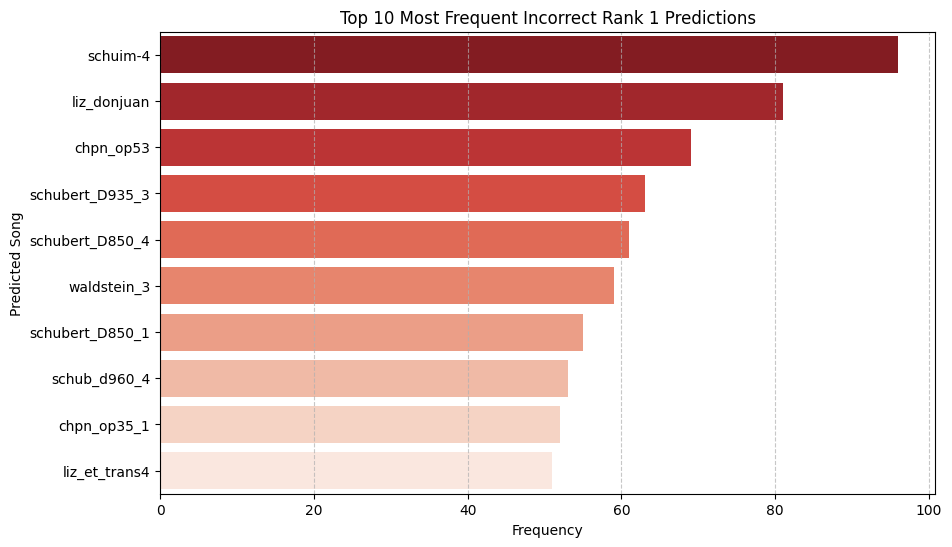

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Filter for valid queries where Rank 1 was incorrect
missed_rank1_df = detailed_df[(detailed_df['Original_Name'] != 'Unknown') &
                              (detailed_df['Original_Name'] != detailed_df['Top_1_Match'])]

print(f"Total queries missed at Rank 1: {len(missed_rank1_df)} out of {total_evaluated}")

# 1. Did it appear in Top 2-5?
caught_in_top5 = 0
for _, row in missed_rank1_df.iterrows():
    true_song = row['Original_Name']
    predicted_2_to_5 = [row[f'Top_{rank}_Match'] for rank in range(2, 6)]
    if true_song in predicted_2_to_5:
        caught_in_top5 += 1

print(f"Caught in Ranks 2-5: {caught_in_top5} ({caught_in_top5/len(missed_rank1_df):.2%})")

# 2. Most common confusions (True Song -> Incorrect Rank 1 Prediction)
confusions = missed_rank1_df.apply(lambda row: f"{row['Original_Name']} -> {row['Top_1_Match']}", axis=1)
top_confusions = Counter(confusions).most_common(10)

print("\n--- Top 10 Most Common Confusions (True -> Predicted) ---")
for conf, count in top_confusions:
    print(f"{count} times: {conf}")

# 3. What is the model predicting most often when it's wrong?
top_wrong_predictions = missed_rank1_df['Top_1_Match'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_wrong_predictions.values, y=top_wrong_predictions.index, hue=top_wrong_predictions.index, palette='Reds_r', legend=False)
plt.title('Top 10 Most Frequent Incorrect Rank 1 Predictions')
plt.xlabel('Frequency')
plt.ylabel('Predicted Song')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


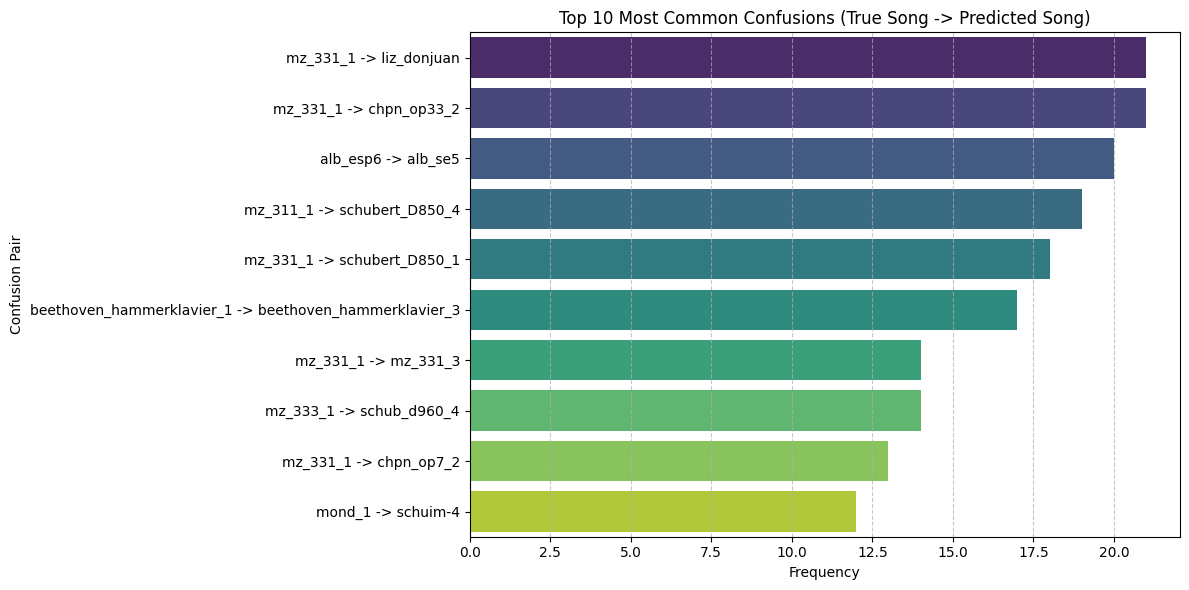

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract labels and counts from top_confusions
conf_labels = [conf for conf, count in top_confusions]
conf_counts = [count for conf, count in top_confusions]

plt.figure(figsize=(12, 6))
sns.barplot(x=conf_counts, y=conf_labels, hue=conf_labels, palette='viridis', legend=False)
plt.title('Top 10 Most Common Confusions (True Song -> Predicted Song)')
plt.xlabel('Frequency')
plt.ylabel('Confusion Pair')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out unknown ground truth
valid_df = detailed_df[detailed_df['Original_Name'] != 'Unknown']

# Split into correct and incorrect Rank 1 predictions
correct_df = valid_df[valid_df['Original_Name'] == valid_df['Top_1_Match']]
incorrect_df = valid_df[valid_df['Original_Name'] != valid_df['Top_1_Match']]

# Calculate mean similarity
mean_sim_correct = correct_df['Top_1_Sim'].mean()
mean_sim_incorrect = incorrect_df['Top_1_Sim'].mean()

print(f"Total Correct Rank 1: {len(correct_df)}")
print(f"Total Incorrect Rank 1: {len(incorrect_df)}")
print(f"\nMean Similarity (Correct Rank 1): {mean_sim_correct:.4f}")
print(f"Mean Similarity (Incorrect Rank 1): {mean_sim_incorrect:.4f}")

# Plot the comparison
plt.figure(figsize=(7, 5))
sns.barplot(x=['Correct Rank 1', 'Incorrect Rank 1'],
            y=[mean_sim_correct, mean_sim_incorrect],
            hue=['Correct Rank 1', 'Incorrect Rank 1'],
            palette='coolwarm', legend=False)
plt.title('Mean Top 1 Similarity: Correct vs Incorrect Predictions')
plt.ylabel('Cosine Similarity')
plt.ylim(0, 1.05)
for i, v in enumerate([mean_sim_correct, mean_sim_incorrect]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()
